In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [6]:
dataset = pd.read_csv('/Users/samarthapc/Documents/college project/dataset/Emails.csv')

In [9]:
dataset.head(10)

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
5,"Subject: great nnews hello , welcome to medzo...",1
6,Subject: here ' s a hot play in motion homela...,1
7,Subject: save your money buy getting this thin...,1
8,Subject: undeliverable : home based business f...,1
9,Subject: save your money buy getting this thin...,1


In [11]:
dataset.sample(10)

,text,spam
3736,"Subject: re : resumes vince , see below for ...",0
4415,Subject: interview with enron dear mr . kamin...,0
2152,"Subject: re : follow up dale , i have passed...",0
1361,Subject: avoid fake viagra get the real thing ...,1
5044,Subject: re : firm power sale from phase i - i...,0
3625,Subject: carnegie mellon candidates kristin :...,0
2814,"Subject: re : thank you ! frank , thanks a l...",0
134,"Subject: get latest version , cds and download...",1
2352,Subject: energy & power risk management 2001 ...,0
4228,"Subject: re : 1 / 2 day kevin , i ' m schedu...",0


In [18]:
dataset.shape

(5728, 2)

In [20]:
dataset.info()
#no missing values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [27]:
dataset.rename(columns={'spam': 'label'},inplace = True)
dataset.sample(5)

,text,label
4610,Subject: the installation of the equipment you...,0
4964,"Subject: ena analyst and associate "" brownbag ...",0
1645,Subject: invoice for energy derivatives course...,0
5043,Subject: re : 2001 fma european conference th...,0
2557,"Subject: re : test thanks , vince . we have r...",0


In [33]:
dataset.duplicated().sum()
#duplicated values

33

In [35]:
dataset = dataset.drop_duplicates(keep= 'first')

In [37]:
dataset.duplicated().sum()
# no duplicate values.

0

# EDA

In [38]:
dataset['label'].value_counts()
# 0 -> ham emails
# 1 -> spam emails.

label
0    4327
1    1368
Name: count, dtype: int64

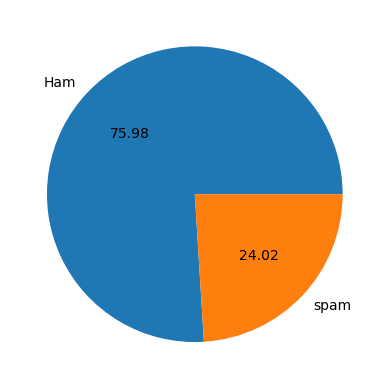

In [41]:
plt.pie(dataset['label'].value_counts(),labels=['Ham','spam'],autopct="%0.2f")
plt.show()

In [68]:
import nltk
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
import string
ps= PorterStemmer()

In [76]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y= []
    for i in text:
        if i.isalnum():
            y.append(i)
    text = y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
        
    return " ".join(y)


        

In [75]:
dataset['text'][20]

"Subject: any med for your girl to be happy !  your girl is unsatisfied with your potency ? don ' t wait until she finds another men !  click here to choose from a great variety of llcensed love t @ bs ! best pri $ es , fast shippinq and guaranteed effect ! here you buy it riqht from warehouse !  the store is verified by bbb and approved by visa ! "

In [78]:
transform_text(lam)

'subject med girl happi girl unsatisfi potenc wait find anoth men click choos great varieti llcens love bs best pri es fast shippinq guarante effect buy riqht warehous store verifi bbb approv visa'

In [80]:
dataset['Transformed text'] = dataset['text'].apply(transform_text)

In [82]:
dataset.head()

,text,label,Transformed text
0,Subject: naturally irresistible your corporate...,1,subject natur irresist corpor ident lt realli ...
1,Subject: the stock trading gunslinger fanny i...,1,subject stock trade gunsling fanni merril muzo...
2,Subject: unbelievable new homes made easy im ...,1,subject unbeliev new home made easi im want sh...
3,Subject: 4 color printing special request add...,1,subject 4 color print special request addit in...
4,"Subject: do not have money , get software cds ...",1,subject money get softwar cd softwar compat gr...


# Model Building


In [84]:
from sklearn.feature_extraction.text import CountVectorizer ,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features = 3000)


In [85]:
X = tfidf.fit_transform(dataset['Transformed text']).toarray()

In [91]:
X.shape

(5695, 3000)

In [92]:
y = dataset['label'].values

In [97]:
y.shape

(5695,)

In [99]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size= 0.2,random_state =2)

# Importing Model


# Naive Bayes

In [113]:
from sklearn.naive_bayes import BernoulliNB,MultinomialNB,GaussianNB
from sklearn.metrics import accuracy_score

In [114]:
b_nb= BernoulliNB()

In [115]:
b_nb.fit(X_train,y_train)
y_pred =b_nb.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.9429323968393327


In [116]:
m_nb= MultinomialNB()

In [117]:
m_nb.fit(X_train,y_train)
y_pred1 = m_nb.predict(X_test)
print(accuracy_score(y_test,y_pred1))

0.9850746268656716


In [118]:
g_nb= GaussianNB()

In [119]:
g_nb.fit(X_train,y_train)
y_pred2 = g_nb.predict(X_test)
print(accuracy_score(y_test,y_pred2))

0.95171202809482


# Logistic Regression

In [120]:
from sklearn.linear_model import LogisticRegression

In [121]:
lr = LogisticRegression()


In [122]:
lr.fit(X_train,y_train)
y_pred3 = lr.predict(X_test)
print(accuracy_score(y_test,y_pred3))

0.9833187006145742
